# A Model of Interacting Basal Ganglia and Cortico-Thalamocortical Loops

## Simulation Time Structure (task epochs)

Simulation time used in the model (ms):

- 1000-2000: instruction cue
- 2000-3000: delay period
- 3000-3100: go cue

<br> Plots use a  −1000 ms offset so that instruction cue onset appears at time 0,  matching the  empirical figures.

<br>Time shown in the plots:


- −400–0 ms:    baseline
- 0–1000 ms:    instruction cue
- 1000–2000 ms: delay period
- 2000–2100 ms: go cue

---

&nbsp;

Noise is excluded here.
Noise values used in the paper to produce more realistic variability are included in the Simulation Noise Control Panel below

In [ ]:
# -------- Imports --------
import numpy as np
import matplotlib.pyplot as plt

# -------- Izhikevich neuron model --------
class Izh:
    def __init__(self, neuron_type):
        self.neuron_type = neuron_type
        self.spike_times = np.array([])

        if self.neuron_type == "RS":
            self.a = 0.03
            self.b = -2.
            self.vreset=-50.
            self.d=100.0
            self.k=0.7
            self.vr=-60.
            self.vt=-40.
            self.vpeak=35.
            self.E=0.
            self.V0=-60.
            self.u0=0.
            self.C=100.


        elif self.neuron_type == "MSN":
            self.a = 0.01
            self.b = -20.
            self.vreset=-55.
            self.d=150.
            self.k=1.
            self.vr=-80.
            self.vt=-25.
            self.vpeak=40.
            self.E=70.
            self.V0=-80.
            self.u0=0.
            self.C=50.


        self.reset_state_variables ()
        self.noise_mean = 0
        self.noise_std = 10
        self.epsilon= np.random.normal(self.noise_mean, self.noise_std, size=tMax)
        self.sigma = 0    # Scaling factor for Gaussian noise term (epsilon);
                          # overridden for selected neuron instances

    def reset_state_variables (self):
        self.v = np.full(tMax, self.V0)
        self.u = np.full(tMax, self.u0)
        self.tempa= np.zeros(tMax)   #Alpha-function values triggered by the most recent presynaptic spike
        self.post = np.zeros(tMax)  # Time series of this neuron's synaptic output (sum of overlapping alpha functions)

    def stimulate(self, Stim, stim_neuron=0):

      # Apply an external stimulus array to this neuron.
      # Used for instruction cues (Somat) and go cues (PPN) at specified time windows.

        for i in range(tMax - 1):
            self.v[i + 1] = self.v[i] +  (self.k * (self.v[i] - self.vr) * (self.v[i] - self.vt)
                 - self.u[i] + self.E + Stim[i]  + self.sigma * self.epsilon[i]) / self.C
            self.u[i + 1] = self.u[i] + self.a * (self.b * (self.v[i] - self.vr) - self.u[i])


            if self.v[i + 1] >= self.vpeak:
                self.v[i] = self.vpeak
                self.v[i + 1] = self.vreset
                self.u[i + 1] = self.u[i + 1] + self.d

                if i < tMax - alphaMax+1:
                    self.tempa = np.concatenate((np.zeros(i), alpha_values, np.zeros(tMax - alphaMax - i)))
                    self.post += self.tempa
                self.spike_times = np.append(self.spike_times, i)

    def spike_and_output (self, i):
        self.v[i] = self.vpeak
        self.v[i + 1] = self.vreset
        self.u[i + 1] += self.d
        if i < tMax - 251:
            self.tempa = np.concatenate((np.zeros(i), alpha_values, np.zeros(tMax - alphaMax - i)))
            self.post += self.tempa
        self.spike_times = np.append(self.spike_times, i)


    # -------- Plotting utilities --------

    def plot_membrane_potential(self, plot_neuron, **kwargs):

        start_index = 600
        end_index = 5000

        plt.figure(figsize=(3,1))

        # The x-axis is offset so that the instruction cue onset corresponds to time 0.
        # And four hundred milliseconds of pre-cue baseline activity are shown.
        # This matches the convention used in most of the empirical figures.

        time_axis = np.arange(start_index, end_index) - 1000

        plt.plot(time_axis, self.v[start_index:end_index], color=graph_color)

        plt.xlim(time_axis[0], time_axis[-1])
        plt.ylim(-100, 100)

        suffix = kwargs.get('suffix','')
        title = f"{plot_neuron}{suffix}"
        plt.title(title)

        plt.ylabel("Potential (mV)")

        #  task epoch markers
        plt.hlines(y=80, xmin=0, xmax=950, color='black', linestyle='-')
        plt.vlines(x=[0,1000,2000], ymin=-100, ymax=100, color='grey', linestyle='--')

        plt.show()


    def short_plot_membrane_potential(self, plot_neuron, plot_start=0, plot_end=4750, **kwargs):

        plt.figure(figsize=(3, 1))  # figure size-- Horiz,Vertical

        plt.plot(np.arange(1, tMax+1), self.v, color=graph_color)
        plt.axis([plot_start, plot_end, -100, 100])

        suffix = kwargs.get('suffix', '')  # Default value is an empty string
        title = f"{plot_neuron}{suffix}"
        plt.title(title)

        plt.ylabel("Potential (mV)")
        plt.hlines(y = 80, xmin = 1000, xmax = 2000, color=graph_color, linestyle = '--', linewidth = 2)

        # The x-axis is offset so that the instruction cue onset corresponds to time 0.
        # And  four hundred milliseconds of pre-cue baseline activity are shown.
        # This matches the convention used in most of the empirical figures.
        current_ticks = plt.gca().get_xticks()  # Get current tick positions
        new_labels = [int(tick) - 1000 for tick in current_ticks]  # Offset each tick label by 1000
        plt.xticks(current_ticks, new_labels)  # Set the new x-tick labels

        plt.show()



# -------- Analysis utilities --------

# SPIKES PER BIN
    def spikes_per_bin (self, neuron_name='', bin_size=1000):
        bin_edges = np.arange(0, tMax + 1, bin_size)
        spike_counts, _ = np.histogram(self.spike_times, bin_edges)
        print()
        print(f"{neuron_name}, bins = {bin_size}")
        print(f"counts={spike_counts}")
        print(f"rates = {spike_counts*1000/bin_size}")







## Circuit Simulation Function

In [ ]:
# -------- Cortico-basal ganglia-thalamic circuit simulation --------
# Simulates the interacting cortical, basal ganglia, and thalamic populations
# during the instruction, delay, and response phases of the task.


def CTC_BG_Circuit(Somat_ALMprep_wt,  Somat_MSNinstr_wt, MSNinstr_SNRinstr_wt, SNRinstr_VMprep_wt, VMprep_ALMprep_wt, ALMprep_VMprep_wt, ALMprep_MSNprep_wt,
                MSNprep_SNRprep_wt, SNRprep_VMresp_wt, PPN_THAL_GO_wt, THAL_GO_ALM_INTER_wt, ALM_INTER_ALMprep_wt, THAL_GO_ALMresp_wt,
                ALMresp_MSNresp_wt, MSNresp_SNRresp_wt, SNRresp_VMresp_wt, VMresp_ALMresp_wt, ALMresp_VMresp_wt):


        # The circuit update operates on neuron instances defined in the
        # "Simulation Parameters and Neuron Instances" section below.

        # Synaptic weights are passed as arguments so that connection strengths
        # can be  modified without changing the circuit code.

        # Each time step updates the interacting cortico–basal ganglia–thalamo–cortical loops.

        # Note: transient silencing can be simulated by clamping v[i+1] = vr
        # for a given neuron over a chosen time interval within the loop below.

        for i in range(tMax - 1):

            MSNinstr.v[i+1] = MSNinstr.v[i]+(MSNinstr.k * (MSNinstr.v[i] - MSNinstr.vr) * (MSNinstr.v[i] - MSNinstr.vt)
                - MSNinstr.u[i] + MSNinstr.E +  Somat.post[i]*Somat_MSNinstr_wt
                + MSNinstr.sigma * MSNinstr.epsilon[i]) / MSNinstr.C
            MSNinstr.u[i + 1] = MSNinstr.u[i] + MSNinstr.a * (MSNinstr.b * (MSNinstr.v[i] - MSNinstr.vr) - MSNinstr.u[i])
            if MSNinstr.v[i + 1] >= MSNinstr.vpeak:
                MSNinstr.spike_and_output(i)

            SNRinstr.v[i+1] = SNRinstr.v[i]+(SNRinstr.k * (SNRinstr.v[i] - SNRinstr.vr) * (SNRinstr.v[i] - SNRinstr.vt)
                - SNRinstr.u[i] + SNRinstr.E - MSNinstr.post[i]*MSNinstr_SNRinstr_wt
                + SNRinstr.sigma * SNRinstr.epsilon[i]) / SNRinstr.C
            SNRinstr.u[i + 1] = SNRinstr.u[i] + SNRinstr.a * (SNRinstr.b * (SNRinstr.v[i] - SNRinstr.vr) - SNRinstr.u[i])
            if SNRinstr.v[i + 1] >= SNRinstr.vpeak:
                 SNRinstr.spike_and_output(i)

            VMprep.v[i+1] = VMprep.v[i]+(VMprep.k * (VMprep.v[i] - VMprep.vr) * (VMprep.v[i] - VMprep.vt)
                - VMprep.u[i] + VMprep.E +  ALMprep.post[i]*ALMprep_VMprep_wt - (SNRinstr.post[i] * SNRinstr_VMprep_wt)
                + VMprep.sigma * VMprep.epsilon[i]) / VMprep.C
            VMprep.u[i + 1] = VMprep.u[i] + VMprep.a * (VMprep.b * (VMprep.v[i] - VMprep.vr) - VMprep.u[i])
            if VMprep.v[i + 1] >= VMprep.vpeak:
                VMprep.spike_and_output(i)

            ALMprep.v[i + 1] = ALMprep.v[i] + (ALMprep.k * (ALMprep.v[i] - ALMprep.vr) * (ALMprep.v[i] - ALMprep.vt)
                - ALMprep.u[i] + ALMprep.E  + Somat.post[i]*Somat_ALMprep_wt+ VMprep.post[i]*VMprep_ALMprep_wt - ALM_INTER.post[i]*ALM_INTER_ALMprep_wt
                + ALMprep.sigma * ALMprep.epsilon[i]) / ALMprep.C
            ALMprep.u[i + 1] = ALMprep.u[i] + ALMprep.a * (ALMprep.b * (ALMprep.v[i] - ALMprep.vr) - ALMprep.u[i])

            if ALMprep.v[i + 1] >= ALMprep.vpeak:
                ALMprep.spike_and_output (i)

            MSNprep.v[i+1] = MSNprep.v[i]+(MSNprep.k * (MSNprep.v[i] - MSNprep.vr) * (MSNprep.v[i] - MSNprep.vt)
                - MSNprep.u[i] + MSNprep.E +  ALMprep.post[i]*ALMprep_MSNprep_wt
                + MSNprep.sigma * MSNprep.epsilon[i]) / MSNprep.C
            MSNprep.u[i + 1] = MSNprep.u[i] + MSNprep.a * (MSNprep.b * (MSNprep.v[i] - MSNprep.vr) - MSNprep.u[i])
            if MSNprep.v[i + 1] >= MSNprep.vpeak:
                MSNprep.spike_and_output(i)

            SNRprep.v[i+1] = SNRprep.v[i]+(SNRprep.k * (SNRprep.v[i] - SNRprep.vr) * (SNRprep.v[i] - SNRprep.vt)
                - SNRprep.u[i] + SNRprep.E -MSNprep.post[i]*MSNprep_SNRprep_wt
                + SNRprep.sigma * SNRprep.epsilon[i]) / SNRprep.C
            SNRprep.u[i + 1] = SNRprep.u[i] + SNRprep.a * (SNRprep.b * (SNRprep.v[i] - SNRprep.vr) - SNRprep.u[i])
            if SNRprep.v[i + 1] >= SNRprep.vpeak:
                 SNRprep.spike_and_output(i)

            THAL_GO.v[i+1] = THAL_GO.v[i]+(THAL_GO.k * (THAL_GO.v[i] - THAL_GO.vr) * (THAL_GO.v[i] - THAL_GO.vt)
                - THAL_GO.u[i] + THAL_GO.E + PPN.post[i]*PPN_THAL_GO_wt
                + THAL_GO.sigma * THAL_GO.epsilon[i]) / THAL_GO.C
            THAL_GO.u[i + 1] = THAL_GO.u[i] + THAL_GO.a * (THAL_GO.b * (THAL_GO.v[i] - THAL_GO.vr) - THAL_GO.u[i])
            if THAL_GO.v[i + 1] >= THAL_GO.vpeak:
                 THAL_GO.spike_and_output(i)

            ALM_INTER.v[i+1] = ALM_INTER.v[i]+(ALM_INTER.k * (ALM_INTER.v[i] - ALM_INTER.vr) * (ALM_INTER.v[i] - ALM_INTER.vt)
                - ALM_INTER.u[i] + ALM_INTER.E + THAL_GO.post[i]*THAL_GO_ALM_INTER_wt
                + ALM_INTER.sigma * ALM_INTER.epsilon[i]) / ALM_INTER.C
            ALM_INTER.u[i + 1] = ALM_INTER.u[i] + ALM_INTER.a * (ALM_INTER.b * (ALM_INTER.v[i] - ALM_INTER.vr) - ALM_INTER.u[i])
            if ALM_INTER.v[i + 1] >= ALM_INTER.vpeak:
                 ALM_INTER.spike_and_output(i)


            VMresp.v[i+1] = VMresp.v[i]+(VMresp.k * (VMresp.v[i] - VMresp.vr) * (VMresp.v[i] - VMresp.vt)
                - VMresp.u[i] + VMresp.E +  (ALMresp.post[i]*ALMresp_VMresp_wt) - (SNRprep.post[i] * SNRprep_VMresp_wt) - (SNRresp.post[i] * SNRresp_VMresp_wt)
                + VMresp.sigma * VMresp.epsilon[i]) / VMresp.C
            VMresp.u[i + 1] = VMresp.u[i] + VMresp.a * (VMresp.b * (VMresp.v[i] - VMresp.vr) - VMresp.u[i])
            if VMresp.v[i + 1] >= VMresp.vpeak:
                VMresp.spike_and_output(i)

            ALMresp.v[i + 1] = ALMresp.v[i] + (ALMresp.k * (ALMresp.v[i] - ALMresp.vr) * (ALMresp.v[i] - ALMresp.vt)
                - ALMresp.u[i] + ALMresp.E  + THAL_GO.post[i]*THAL_GO_ALMresp_wt   + VMresp.post[i]*VMresp_ALMresp_wt + ALMresp.sigma * ALMresp.epsilon[i]) / ALMresp.C
            ALMresp.u[i + 1] = ALMresp.u[i] + ALMresp.a * (ALMresp.b * (ALMresp.v[i] - ALMresp.vr) - ALMresp.u[i])
            if ALMresp.v[i + 1] >= ALMresp.vpeak:
                ALMresp.spike_and_output (i)

            MSNresp.v[i+1] = MSNresp.v[i]+(MSNresp.k * (MSNresp.v[i] - MSNresp.vr) * (MSNresp.v[i] - MSNresp.vt)
                - MSNresp.u[i] + MSNresp.E  + ALMresp.post[i]*ALMresp_MSNresp_wt
                + MSNresp.sigma * MSNresp.epsilon[i]) / MSNresp.C
            MSNresp.u[i + 1] = MSNresp.u[i] + MSNresp.a * (MSNresp.b * (MSNresp.v[i] - MSNresp.vr) - MSNresp.u[i])
            if MSNresp.v[i + 1] >= MSNresp.vpeak:
                MSNresp.spike_and_output(i)

            SNRresp.v[i+1] = SNRresp.v[i]+(SNRresp.k * (SNRresp.v[i] - SNRresp.vr) * (SNRresp.v[i] - SNRresp.vt)
                - SNRresp.u[i] + SNRresp.E - (MSNresp.post[i]*MSNresp_SNRresp_wt)
                + SNRresp.sigma * SNRresp.epsilon[i]) / SNRresp.C
            SNRresp.u[i + 1] = SNRresp.u[i] + SNRresp.a * (SNRresp.b * (SNRresp.v[i] - SNRresp.vr) - SNRresp.u[i])
            if SNRresp.v[i + 1] >= SNRresp.vpeak:
                 SNRresp.spike_and_output(i)



## Simulation Settings and Neuron Instances

In [ ]:

tMax = 5000


# -------- Simulation Noise Control Panel --------
# Sigma is set to 0 for deterministic/mechanistic verification of the model's temporal architecture.
# To see the representative trial-to-trial variability (physiologial noise) shown in the paper's
# figures, use the recommended values listed in the comments below.

# Recommended values to approximate the visual realism shown in many of the manuscript figures (e.g., Figures 3 and 4)
sigma_Somat    = 0     # Recommend: 35 (for realistic variability)
sigma_SNRinstr = 0     # Recommend: 35
sigma_VMprep   = 0     # Recommend: 30
sigma_PPN      = 0     # Recommend: 35
sigma_SNRprep  = 0     # Recommend: 35
sigma_VMresp   = 0     # Recommend: 40

# -------- Model setup --------

# -------- Create neuron instances --------
  # Instantiate neurons for a basal ganglia channel and associated cortical/thalamic nodes
  # Naming convention:
  #   instr = instruction phase
  #   prep = delay phase
  #   resp = response phase

Somat=Izh ('RS')
Somat.sigma = sigma_Somat

MSNinstr=Izh('MSN')

MSNprep=Izh('MSN')

MSNresp=Izh ('MSN')

SNRinstr = Izh ('RS')
SNRinstr.E = 120  # tonic depolarizing input producing baseline firing
SNRinstr.sigma = sigma_SNRinstr

ALMprep=Izh('RS')

VMprep=Izh('RS')
VMprep.sigma = sigma_VMprep

PPN=Izh ('RS')
PPN.E=100
PPN.sigma = sigma_PPN

THAL_GO=Izh('RS')

ALM_INTER=Izh('RS')

SNRprep=Izh('RS')
SNRprep.E=120
SNRprep.sigma = sigma_SNRprep

SNRresp=Izh('RS')
SNRresp.E=120

ALMresp= Izh('RS')

VMresp=Izh('RS')
VMresp.sigma = sigma_VMresp


# -------- Experimental condition: cue configuration --------
  # preferred: instruction cue matches the BG channel being recorded
  # control:   instruction cue targets the parallel BG channel

cue_condition = "preferred"   # "preferred" or "control"

if cue_condition == "preferred":
    graph_color = "blue"
    W_Sample = 150   # Instruction cue input to Somat neuron
else:
    graph_color = "red"
    W_Sample = 0     # No input to Somat neuron (e.g., alternative cue)

suffix = ""

W_go = 850  # Go cue input to PPN neuron

##Synaptic Weights and Task Inputs

In [ ]:
# -------- Synaptic weights --------
# Weights represent synaptic strength between named populations.
# Connections shown as negative in the manuscript are applied with a
# minus sign in the membrane equation.

Somat_ALMprep = 40 # weight of the synapse between Somat and ALMprep
Somat_MSNinstr = 220
MSNinstr_SNRinstr = 90
SNRinstr_VMprep = 10
VMprep_ALMprep = 70
ALMprep_VMprep = 80
ALMprep_MSNprep = 320
MSNprep_SNRprep = 50
SNRprep_VMresp = 100
VMresp_ALMresp = 85
ALMresp_VMresp = 90
PPN_THAL_GO = 60
THAL_GO_ALM_INTER = 55
THAL_GO_ALMresp = 30
ALM_INTER_ALMprep = 50
ALMresp_MSNresp = 320
MSNresp_SNRresp = 90
SNRresp_VMresp = 50

# -------- Alpha values --------
# Alpha function describing the synaptic output produced by a single spike

alphaMax=250
td = np.arange(1, alphaMax+1)
L=30
alpha_values = td/L * np.exp((L-td)/L)

# -------- Stimulus inputs --------
Sample = np.zeros(tMax)  # Instruction cue input
Go_cue = np.zeros(tMax)   # Go cue input
Sample_start = 1000
Sample_end = 2000    # instruction cue period

Sample [Sample_start:Sample_end] = W_Sample
Go_start = 3000
Go_end = 3100   # go cue period
Go_cue [Go_start:Go_end] = W_go

Somat.stimulate(Sample, stim_neuron=1) # Apply instruction cue to Somat
PPN.stimulate(Go_cue)    # Apply go cue

# -------- Run circuit simulation --------
CTC_BG_Circuit (
    Somat_ALMprep_wt      = Somat_ALMprep,
    Somat_MSNinstr_wt     = Somat_MSNinstr,
    MSNinstr_SNRinstr_wt  = MSNinstr_SNRinstr,
    SNRinstr_VMprep_wt    = SNRinstr_VMprep,
    VMprep_ALMprep_wt     = VMprep_ALMprep,
    ALMprep_VMprep_wt     = ALMprep_VMprep,
    ALMprep_MSNprep_wt    = ALMprep_MSNprep,
    MSNprep_SNRprep_wt    = MSNprep_SNRprep,
    SNRprep_VMresp_wt     = SNRprep_VMresp,
    PPN_THAL_GO_wt        = PPN_THAL_GO,
    THAL_GO_ALM_INTER_wt  = THAL_GO_ALM_INTER,
    ALM_INTER_ALMprep_wt  = ALM_INTER_ALMprep,
    THAL_GO_ALMresp_wt    = THAL_GO_ALMresp,
    ALMresp_MSNresp_wt    = ALMresp_MSNresp,
    MSNresp_SNRresp_wt    = MSNresp_SNRresp,
    SNRresp_VMresp_wt     = SNRresp_VMresp,
    VMresp_ALMresp_wt     = VMresp_ALMresp,
    ALMresp_VMresp_wt     = ALMresp_VMresp)


## Model Output and Activity Plots

Sample: 150 SNR background: 120 ; PPN background= 100
ALM_prep is an RS neuron
Weights:
Somat_ALM:40; Somat_MSNinstr:220;MSNinstr_SNRinstr 90; SNRinstr_VMprep:10; VMprep_ALMprep:70;  ALMprep_VMprep:80;   ALMprep_MSNprep:320; MSNprep_SNRprep: 50;  SNRprep_VMresp: 100; PPN_THAL_GO:60; THAL_GO_ALM_INTER:55
ALM_INTER_ALMprep:50; ALMresp_MSNresp:320; SNRresp_VMresp:50

SNRresp: -2962.0

PPN, bins = 500
counts=[ 6  7  7  6  7  6 18  6  7  7]
rates = [12. 14. 14. 12. 14. 12. 36. 12. 14. 14.]

THAL_GO, bins = 500
counts=[ 2  3  3  3  3  3 12  3  3  2]
rates = [ 4.  6.  6.  6.  6.  6. 24.  6.  6.  4.]

ALM_INTER, bins = 500
counts=[0 0 0 0 0 0 8 0 0 0]
rates = [ 0.  0.  0.  0.  0.  0. 16.  0.  0.  0.]

ALM_resp, bins = 500
counts=[ 0  0  0  0  0  0 10  0  0  0]
rates = [ 0.  0.  0.  0.  0.  0. 20.  0.  0.  0.]

VMresp, bins = 500
counts=[0 0 0 0 0 0 5 0 0 0]
rates = [ 0.  0.  0.  0.  0.  0. 10.  0.  0.  0.]

ALMresp, bins = 100
counts=[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

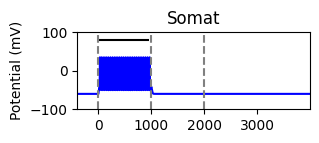

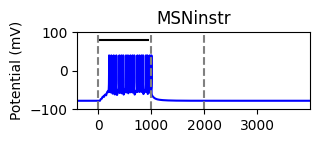

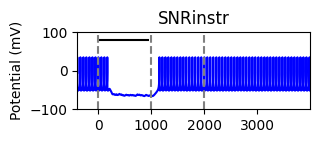

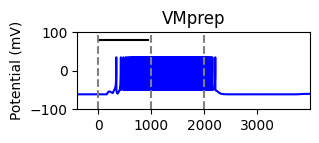

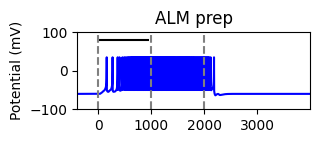

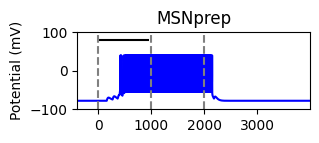

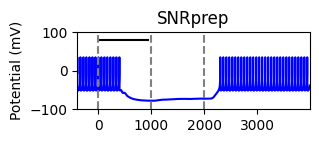

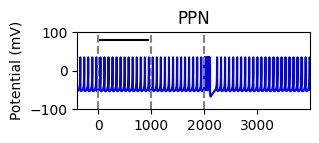

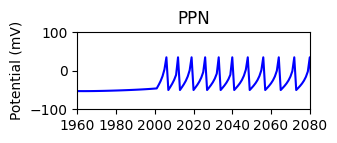

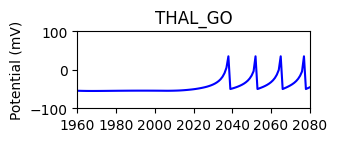

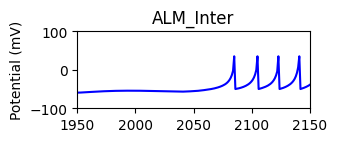

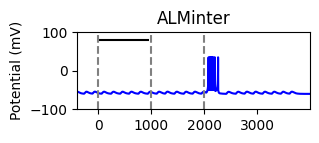

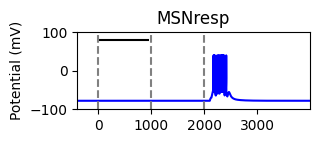

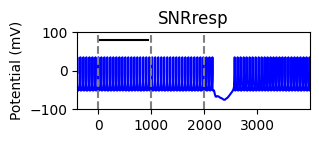

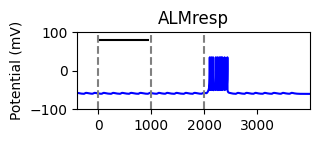

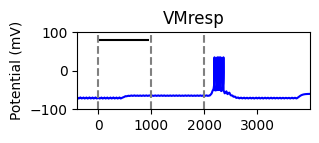

In [ ]:
# --------DESCRIPTION--------
label=''
print('Sample:',W_Sample, 'SNR background:', SNRinstr.E, '; PPN background=',PPN.E)

print (f'ALM_prep is an {ALMprep.neuron_type} neuron')

print("Weights:")
print(f"Somat_ALM:{Somat_ALMprep}; Somat_MSNinstr:{Somat_MSNinstr};MSNinstr_SNRinstr {MSNinstr_SNRinstr}; SNRinstr_VMprep:{SNRinstr_VMprep}; VMprep_ALMprep:{VMprep_ALMprep};\
  ALMprep_VMprep:{ALMprep_VMprep};   ALMprep_MSNprep:{ALMprep_MSNprep}; MSNprep_SNRprep: {MSNprep_SNRprep};  SNRprep_VMresp: {SNRprep_VMresp}; PPN_THAL_GO:{PPN_THAL_GO}; THAL_GO_ALM_INTER:{THAL_GO_ALM_INTER}")
print(f"ALM_INTER_ALMprep:{ALM_INTER_ALMprep}; ALMresp_MSNresp:{ALMresp_MSNresp}; SNRresp_VMresp:{SNRresp_VMresp}")

print()

# -------- ANALYSES --------
from IPython.display import HTML


SNRresp_lat=SNRresp.spike_times[0]-Go_start  #with no noise
print ("SNRresp:", SNRresp_lat)


# -------- SPIKES PER BIN --------
PPN.spikes_per_bin (neuron_name='PPN', bin_size=500)
THAL_GO.spikes_per_bin (neuron_name='THAL_GO', bin_size=500)
ALM_INTER.spikes_per_bin (neuron_name='ALM_INTER', bin_size=500)
ALMresp.spikes_per_bin (neuron_name='ALM_resp', bin_size=500)
VMresp.spikes_per_bin (neuron_name="VMresp", bin_size=500)
ALMresp.spikes_per_bin (neuron_name='ALMresp', bin_size=100)


# -------- Plot neuron activity --------
Somat.plot_membrane_potential(plot_neuron="Somat", suffix=suffix, label=label)
MSNinstr.plot_membrane_potential(plot_neuron="MSNinstr", suffix=suffix,label=label)
SNRinstr.plot_membrane_potential(plot_neuron="SNRinstr",suffix=suffix, label=label)
VMprep.plot_membrane_potential(plot_neuron="VMprep",suffix=suffix, label=label)
ALMprep.plot_membrane_potential(plot_neuron="ALM prep", suffix=suffix,label=label)
MSNprep.plot_membrane_potential(plot_neuron="MSNprep", suffix=suffix,label=label)
SNRprep.plot_membrane_potential(plot_neuron="SNRprep", suffix=suffix,label=label)
PPN.plot_membrane_potential(plot_neuron="PPN", suffix=suffix,)
PPN.short_plot_membrane_potential(plot_neuron="PPN",  plot_start=2970, plot_end=3070, suffix=suffix)
THAL_GO.short_plot_membrane_potential(plot_neuron="THAL_GO",  plot_start=2970, plot_end=3070)
ALM_INTER.short_plot_membrane_potential(plot_neuron="ALM_Inter",  plot_start=2950, plot_end=3150)
ALM_INTER.plot_membrane_potential(plot_neuron="ALMinter", suffix=suffix,label=label)
MSNresp.plot_membrane_potential(plot_neuron="MSNresp")
SNRresp.plot_membrane_potential(plot_neuron="SNRresp", suffix=suffix)
ALMresp.plot_membrane_potential(plot_neuron="ALMresp", suffix=suffix)
VMresp.plot_membrane_potential(plot_neuron="VMresp", suffix=suffix, label=label)
